<a href="https://colab.research.google.com/github/shivanshu1113/Basic_ML_Models/blob/main/Heart_Disease_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Importing the Dependencies

In [1]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, confusion_matrix, classification_report,
                             roc_auc_score, roc_curve, ConfusionMatrixDisplay)
import matplotlib.pyplot as plt
import joblib
import seaborn as sns
from sklearn.inspection import permutation_importance

Data Collection and Processing

In [2]:
# loading the csv data to a Pandas DataFrame
heart_data = pd.read_csv('/content/heart_disease_data.csv')

In [3]:
# print first 5 rows of the dataset
heart_data.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


In [4]:
# print last 5 rows of the dataset
heart_data.tail()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
298,57,0,0,140,241,0,1,123,1,0.2,1,0,3,0
299,45,1,3,110,264,0,1,132,0,1.2,1,0,3,0
300,68,1,0,144,193,1,1,141,0,3.4,1,2,3,0
301,57,1,0,130,131,0,1,115,1,1.2,1,1,3,0
302,57,0,1,130,236,0,0,174,0,0.0,1,1,2,0


In [5]:
# number of rows and columns in the dataset
heart_data.shape

(303, 14)

In [6]:
# getting some info about the data
heart_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trestbps  303 non-null    int64  
 4   chol      303 non-null    int64  
 5   fbs       303 non-null    int64  
 6   restecg   303 non-null    int64  
 7   thalach   303 non-null    int64  
 8   exang     303 non-null    int64  
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    int64  
 11  ca        303 non-null    int64  
 12  thal      303 non-null    int64  
 13  target    303 non-null    int64  
dtypes: float64(1), int64(13)
memory usage: 33.3 KB


In [7]:
# checking for missing values
heart_data.isnull().sum()

,0
age,0
sex,0
cp,0
trestbps,0
chol,0
fbs,0
restecg,0
thalach,0
exang,0
oldpeak,0


In [8]:
# statistical measures about the data
heart_data.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000
mean,54.366337,0.683168,0.966997,131.623762,246.264026,0.148515,0.528053,149.646865,0.326733,1.039604,1.399340,0.729373,2.313531,0.544554
std,9.082101,0.466011,1.032052,17.538143,51.830751,0.356198,0.525860,22.905161,0.469794,1.161075,0.616226,1.022606,0.612277,0.498835
min,29.000000,0.000000,0.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,47.500000,0.000000,0.000000,120.000000,211.000000,0.000000,0.000000,133.500000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,55.000000,1.000000,1.000000,130.000000,240.000000,0.000000,1.000000,153.000000,0.000000,0.800000,1.000000,0.000000,2.000000,1.000000
75%,61.000000,1.000000,2.000000,140.000000,274.500000,0.000000,1.000000,166.000000,1.000000,1.600000,2.000000,1.000000,3.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000,1.000000


In [9]:
# checking the distribution of Target Variable
heart_data['target'].value_counts()

,count
target,
1,165
0,138


1 --> Defective Heart

0 --> Healthy Heart

Splitting the Features and Target

In [10]:
# Separate features & target
X = heart_data.drop(columns='target', axis=1)
Y = heart_data['target']

In [11]:
print(X)

     age  sex  cp  trestbps  chol  fbs  restecg  thalach  exang  oldpeak  \
0     63    1   3       145   233    1        0      150      0      2.3   
1     37    1   2       130   250    0        1      187      0      3.5   
2     41    0   1       130   204    0        0      172      0      1.4   
3     56    1   1       120   236    0        1      178      0      0.8   
4     57    0   0       120   354    0        1      163      1      0.6   
..   ...  ...  ..       ...   ...  ...      ...      ...    ...      ...   
298   57    0   0       140   241    0        1      123      1      0.2   
299   45    1   3       110   264    0        1      132      0      1.2   
300   68    1   0       144   193    1        1      141      0      3.4   
301   57    1   0       130   131    0        1      115      1      1.2   
302   57    0   1       130   236    0        0      174      0      0.0   

     slope  ca  thal  
0        0   0     1  
1        0   0     2  
2        2   0    

In [12]:
print(Y)

0      1
1      1
2      1
3      1
4      1
      ..
298    0
299    0
300    0
301    0
302    0
Name: target, Length: 303, dtype: int64


Splitting the Data into Training data & Test Data

In [13]:
X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y, test_size=0.2, stratify=Y, random_state=2
)

In [14]:
pipe_lr = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', LogisticRegression(max_iter=2000, solver='lbfgs'))
])

Model Training

Logistic Regression

In [15]:
pipe_lr.fit(X_train, Y_train)

Pipeline(steps=[('scaler', StandardScaler()),
                ('clf', LogisticRegression(max_iter=2000))])

In [16]:
Y_train_pred = pipe_lr.predict(X_train)
Y_test_pred  = pipe_lr.predict(X_test)

In [17]:
print("Training Accuracy:", accuracy_score(Y_train, Y_train_pred))
print("Testing Accuracy :", accuracy_score(Y_test, Y_test_pred))
print("\nClassification Report:\n", classification_report(Y_test, Y_test_pred))

Training Accuracy: 0.8471074380165289
Testing Accuracy : 0.7868852459016393

Classification Report:
               precision    recall  f1-score   support

           0       0.76      0.79      0.77        28
           1       0.81      0.79      0.80        33

    accuracy                           0.79        61
   macro avg       0.79      0.79      0.79        61
weighted avg       0.79      0.79      0.79        61



In [18]:
# ----- 1) Cross-Validation Score -----
cv_scores = cross_val_score(pipe_lr, X, Y, cv=5, scoring='accuracy')
print("5-Fold CV Accuracy: Mean = {:.3f}, Std = {:.3f}".format(cv_scores.mean(), cv_scores.std()))

5-Fold CV Accuracy: Mean = 0.835, Std = 0.041


In [22]:
# ----- 2) Hyperparameter Search -----

param_grid = [
    {
        'clf': [LogisticRegression(max_iter=2000, solver='liblinear')],
        'clf__C': [0.03, 0.1, 1, 10, 100],
        'clf__penalty': ['l1', 'l2']
    },
    {
        'clf': [RandomForestClassifier(random_state=2)],
        'clf__n_estimators': [100, 200,500],
        'clf__max_depth': [None, 5, 10,15],
        'clf__min_samples_split': [2, 5,7]
    }
]

# Pipeline placeholder for GS
pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', LogisticRegression())
])

gs = GridSearchCV(pipe, param_grid, cv=5, scoring='accuracy', n_jobs=-1, verbose=1)
gs.fit(X_train, Y_train)

print("\nBest Parameters:", gs.best_params_)
print("Best CV Score  :", gs.best_score_)

best_model = gs.best_estimator_

Fitting 5 folds for each of 46 candidates, totalling 230 fits

Best Parameters: {'clf': RandomForestClassifier(random_state=2), 'clf__max_depth': 10, 'clf__min_samples_split': 2, 'clf__n_estimators': 200}
Best CV Score  : 0.8551870748299321


Test Accuracy: 0.7541

Classification Report:
              precision    recall  f1-score   support

           0       0.72      0.75      0.74        28
           1       0.78      0.76      0.77        33

    accuracy                           0.75        61
   macro avg       0.75      0.75      0.75        61
weighted avg       0.76      0.75      0.75        61

Confusion Matrix:
 [[21  7]
 [ 8 25]]


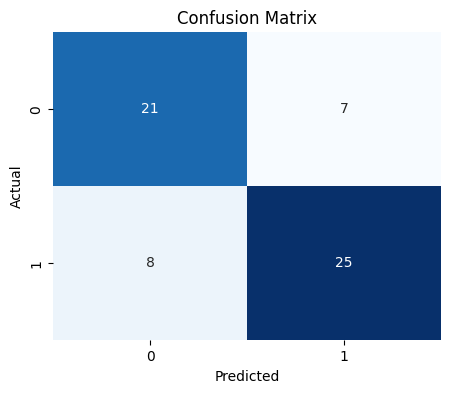

ROC AUC: 0.8701


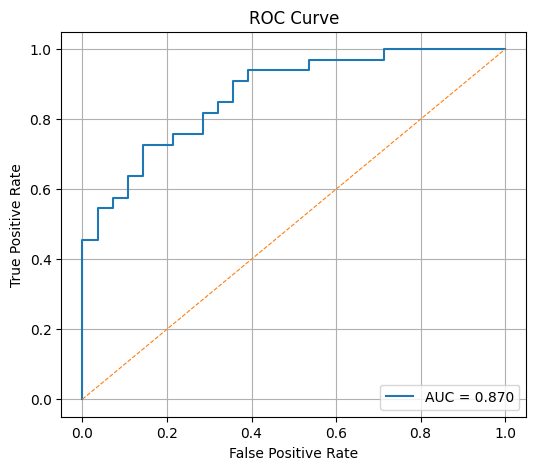

In [20]:
# --- allow either naming convention (y_test or Y_test) ---
try:
    y_test_var = y_test  # most common in the notebook
except NameError:
    try:
        y_test_var = Y_test
    except NameError:
        raise NameError("Neither 'y_test' nor 'Y_test' is defined in the namespace.")

try:
    X_test_var = X_test
except NameError:
    try:
        X_test_var = X_test  # fallback (redundant but explicit)
    except NameError:
        raise NameError("X_test is not defined in the namespace.")

# --- Predictions ---
y_pred = best_model.predict(X_test_var)

# If model supports predict_proba, use it for ROC/AUC; otherwise try decision_function
if hasattr(best_model, "predict_proba"):
    y_proba = best_model.predict_proba(X_test_var)[:, 1]
elif hasattr(best_model, "decision_function"):
    y_proba = best_model.decision_function(X_test_var)
else:
    y_proba = None

# --- Metrics ---
acc = accuracy_score(y_test_var, y_pred)
print(f"Test Accuracy: {acc:.4f}\n")
print("Classification Report:")
print(classification_report(y_test_var, y_pred))

cm = confusion_matrix(y_test_var, y_pred)
print("Confusion Matrix:\n", cm)

# --- Confusion matrix heatmap ---
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

# --- ROC / AUC (if probabilities available) ---
if y_proba is not None:
    auc = roc_auc_score(y_test_var, y_proba)
    fpr, tpr, _ = roc_curve(y_test_var, y_proba)
    print(f"ROC AUC: {auc:.4f}")

    plt.figure(figsize=(6,5))
    plt.plot(fpr, tpr, label=f'AUC = {auc:.3f}')
    plt.plot([0,1], [0,1], linestyle='--', linewidth=0.8)
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('ROC Curve')
    plt.legend(loc='lower right')
    plt.grid(True)
    plt.show()
else:
    print("No probability scores available for ROC/AUC (model lacks predict_proba/decision_function).")


Computing permutation importances (may take some time)...
Top permutation importances:
     feature  importance_mean  importance_std
12      thal         0.045902        0.024093
9    oldpeak         0.026230        0.024535
7    thalach         0.009836        0.026636
1        sex         0.009836        0.010874
10     slope         0.008197        0.008197
4       chol         0.006557        0.010874
2         cp         0.001639        0.033955
3   trestbps        -0.008197        0.015114
6    restecg        -0.011475        0.007512
0        age        -0.011475        0.019466
5        fbs        -0.014754        0.004918
8      exang        -0.018033        0.018619
11        ca        -0.022951        0.037526


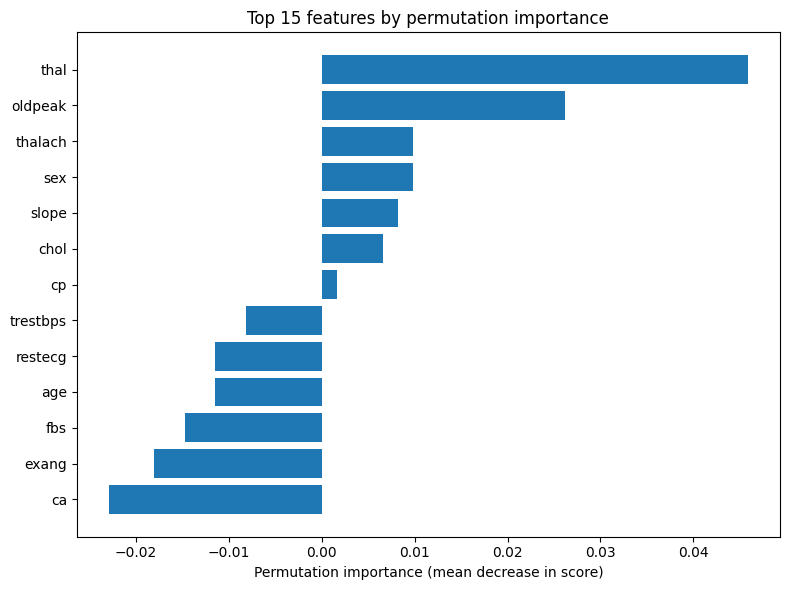


SHAP available — computing SHAP values (may be slow).
Plotting SHAP summary plot (local display).


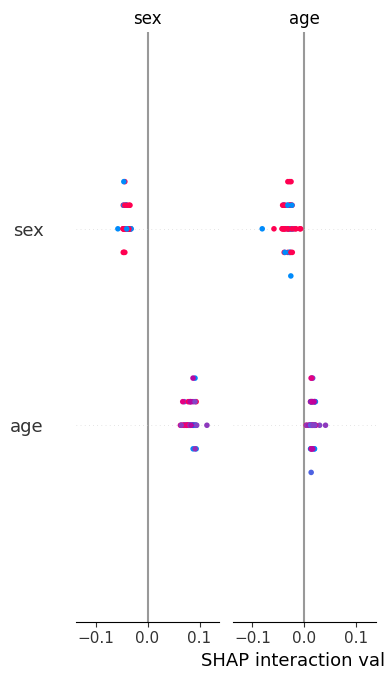


Saved best model to best_model.joblib


In [21]:
# --- 1) Feature importances (works for tree models / linear models) ---
feature_names = X_train.columns if hasattr(X_train, "columns") else [f"f{i}" for i in range(X_train.shape[1])]

# Model-specific importances (trees / linear models)
if hasattr(best_model, "feature_importances_"):
    importances = best_model.feature_importances_
    fi_df = pd.DataFrame({"feature": feature_names, "importance": importances}).sort_values("importance", ascending=False)
    print("Model feature_importances_ (tree-based):")
    print(fi_df)
elif hasattr(best_model, "coef_"):
    # If it's a pipeline, grab coef_ from the final estimator
    try:
        coef = best_model.coef_
    except Exception:
        # attempt to get last step
        try:
            coef = best_model.named_steps[list(best_model.named_steps.keys())[-1]].coef_
        except Exception:
            coef = None
    if coef is not None:
        # handle multiclass / 1D
        coef_flat = coef.ravel() if coef.ndim > 1 else coef
        fi_df = pd.DataFrame({"feature": feature_names, "coef": coef_flat}).sort_values("coef", key=abs, ascending=False)
        print("Model coefficients (linear model):")
        print(fi_df)
    else:
        print("No feature_importances_ or coef_ available on model.")

# --- 2) Permutation importance (model-agnostic, slower but robust) ---
print("\nComputing permutation importances (may take some time)...")
perm = permutation_importance(best_model, X_test_var, y_test_var, n_repeats=10, random_state=42, n_jobs=-1)
perm_df = pd.DataFrame({"feature": feature_names, "importance_mean": perm.importances_mean, "importance_std": perm.importances_std})
perm_df = perm_df.sort_values("importance_mean", ascending=False)
print("Top permutation importances:")
print(perm_df.head(15))

# Optional: quick bar plot for permutation importances
import matplotlib.pyplot as plt
plt.figure(figsize=(8,6))
plt.barh(perm_df["feature"].head(15)[::-1], perm_df["importance_mean"].head(15)[::-1])
plt.xlabel("Permutation importance (mean decrease in score)")
plt.title("Top 15 features by permutation importance")
plt.tight_layout()
plt.show()

# --- 3) Optional: SHAP explanations (if installed) ---
try:
    import shap
    print("\nSHAP available — computing SHAP values (may be slow).")
    # If model is a pipeline, get the final estimator for SHAP's explainer if needed
    estimator_for_shap = best_model
    if hasattr(best_model, "named_steps"):
        # try final estimator
        estimator_for_shap = list(best_model.named_steps.values())[-1]

    explainer = None
    # TreeExplainer for tree models, otherwise KernelExplainer (slower)
    if hasattr(estimator_for_shap, "predict_proba") and hasattr(estimator_for_shap, "feature_importances_"):
        explainer = shap.TreeExplainer(estimator_for_shap)
    else:
        # use a small background set for KernelExplainer
        background = shap.sample(X_train, 100) if X_train.shape[0] > 100 else X_train
        explainer = shap.KernelExplainer(estimator_for_shap.predict_proba if hasattr(estimator_for_shap, "predict_proba") else estimator_for_shap.predict, background)

    # compute SHAP values for a sample of test rows
    X_shap = shap.sample(X_test, 50) if X_test.shape[0] > 50 else X_test
    shap_values = explainer.shap_values(X_shap)
    print("Plotting SHAP summary plot (local display).")
    shap.summary_plot(shap_values, X_shap, feature_names=list(feature_names))
except Exception as e:
    print("SHAP not used (not installed or failed). Reason:", e)

# --- 4) Save the best model to disk (joblib) ---
model_path = "best_model.joblib"
joblib.dump(best_model, model_path)
print(f"\nSaved best model to {model_path}")

# --- 5) Helper: load model and predict on a single new sample ---
def load_model(path="best_model.joblib"):
    return joblib.load(path)

def predict_single(sample, model=None):
    """
    sample: dict or 1D array-like or pandas Series matching feature order in X_train
    model: optional loaded model; if None, will load from model_path
    """
    if model is None:
        model = load_model(model_path)

    # convert dict to DataFrame row using feature_names to ensure correct order
    if isinstance(sample, dict):
        row = pd.DataFrame([sample], columns=feature_names)
    elif isinstance(sample, (list, tuple, np.ndarray)):
        row = pd.DataFrame([sample], columns=feature_names)
    elif isinstance(sample, pd.Series):
        row = sample.to_frame().T.reindex(columns=feature_names)
    else:
        raise ValueError("Unsupported sample type. Provide dict, list/array, or pandas Series.")

    pred = model.predict(row)
    proba = model.predict_proba(row)[:,1] if hasattr(model, "predict_proba") else None
    return {"prediction": int(pred[0]), "probability": float(proba[0]) if proba is not None else None}